In [1]:

from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

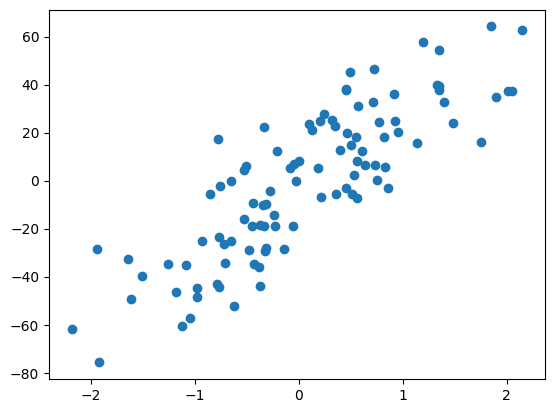

In [3]:

plt.scatter(X,y)

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:

lr = LinearRegression()

In [7]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [8]:

y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [12]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)
        
    def predict(self,X):
        return self.m * X + self.b

In [10]:

gd = GDRegressor(0.001,50)

In [11]:

gd.fit(X_train,y_train)

28.159367347119066 -2.3004574196824854


In [ ]:

y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

#  Gradient Descent step by Step

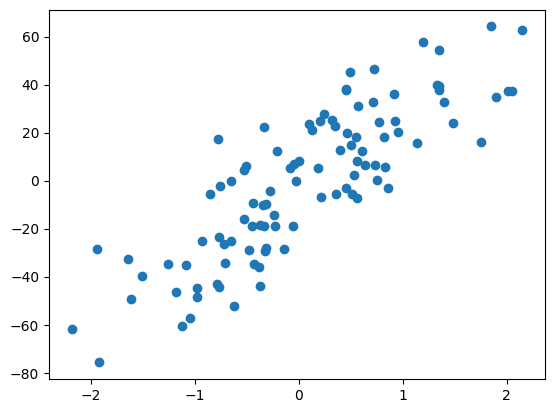

In [14]:


import matplotlib.pyplot as plt
plt.scatter(X,y)

In [15]:


# Lets apply OLS
from sklearn.linear_model import LinearRegression
     

In [16]:


reg = LinearRegression()
reg.fit(X,y)
     

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
reg.coef_

array([27.82809103])

In [18]:
reg.intercept_

np.float64(-2.29474455867698)

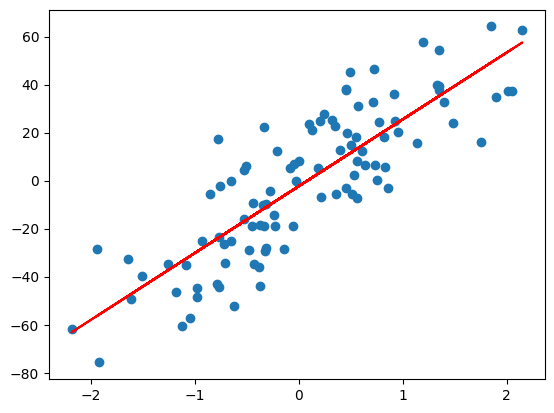

In [19]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [20]:


# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 100).reshape(4)
     



KeyboardInterrupt



ValueError: x and y must have same first dimension, but have shapes (100, 1) and (20,)

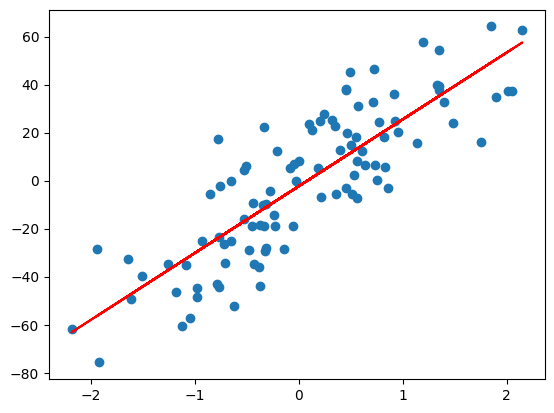

In [22]:


plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()


In [23]:


m = 78.35
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope
     

np.float64(21049.119491445497)

In [24]:


# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size
     

np.float64(2104.91194914455)

In [25]:


# Calculating the new intercept
b = b - step_size
b

np.float64(-2004.91194914455)

In [28]:
y_pred1 = ((78.35 * X) + b).reshape(100)       # 1D array of length 100
y_pred1 = ((78.35 * X) + b).reshape(-1,1)      # Column vector (100x1)
y_pred1 = ((78.35 * X) + b).reshape(10,10)     # 2D grid (10x10)


ValueError: x and y must have same first dimension, but have shapes (100, 1) and (20,)

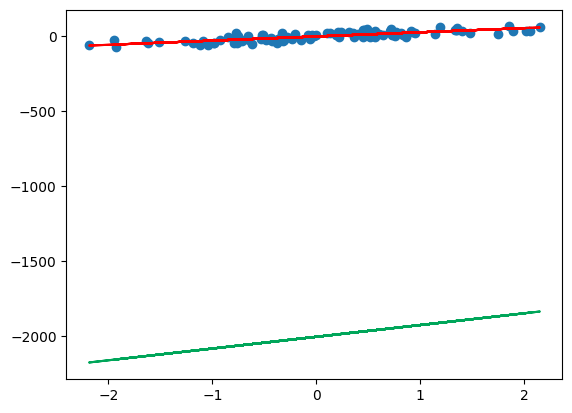

In [29]:
y_pred1 = ((78.35 * X) + b).reshape(-1)   # 100 values in 1D

plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred1, color='#00a65a', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 0')
plt.legend()
plt.show()


In [30]:


# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-399933.27033746446)

In [31]:


step_size = loss_slope*lr
step_size
     


np.float64(-39993.32703374645)

In [32]:


b = b - step_size
b

np.float64(37988.4150846019)

ValueError: x and y must have same first dimension, but have shapes (100, 1) and (20,)

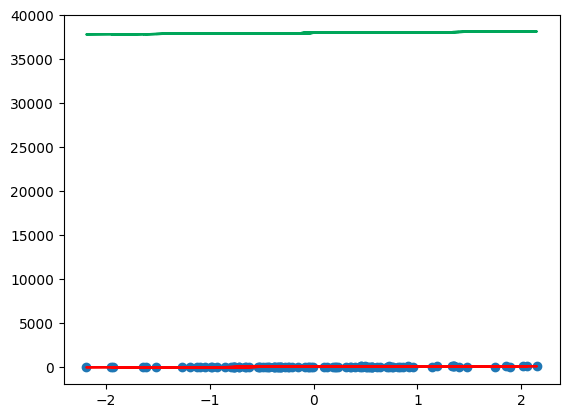

In [34]:
y_pred1 = ((78.35 * X) + b).reshape(-1)   # 100 values
y_pred2 = ((78.35 * X) + b).reshape(-1)   # same formula, अलग color

plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred1, color='#00a65a', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 0')
plt.legend()
plt.show()


In [35]:


# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(7598732.136411824)

In [36]:


step_size = loss_slope*lr
step_size

np.float64(759873.2136411825)

In [37]:


b = b - step_size
b
     

np.float64(-721884.7985565807)

ValueError: x and y must have same first dimension, but have shapes (100, 1) and (20,)

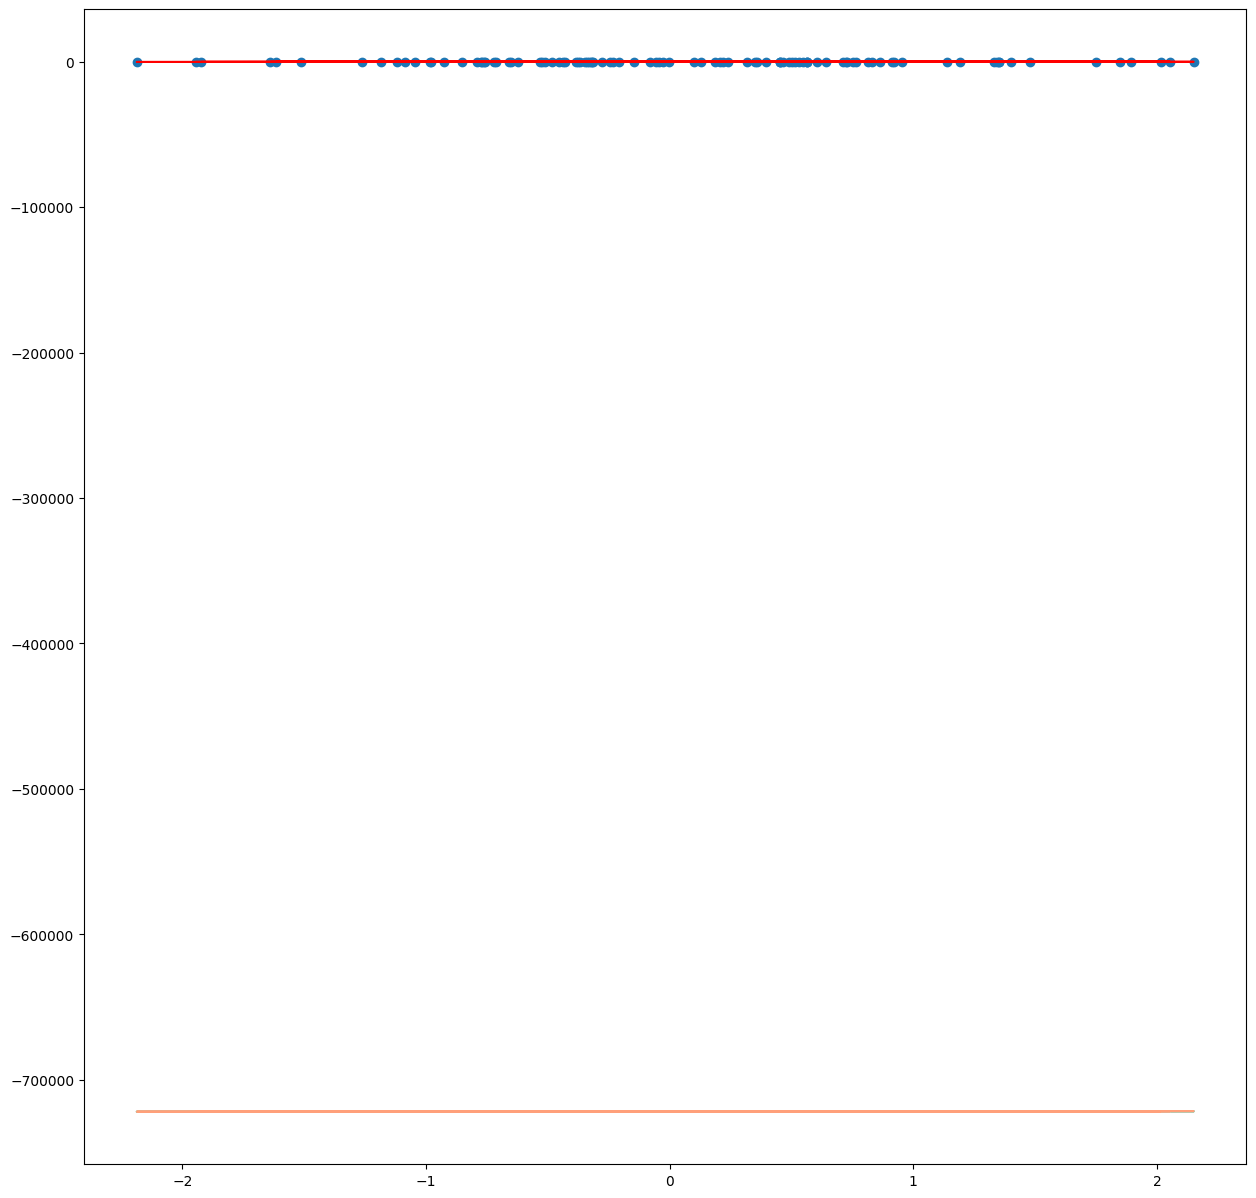

In [39]:
y_pred1 = ((78.35 * X) + b).reshape(-1)   # 100 values
y_pred2 = ((50 * X) + b).reshape(-1)      # अलग slope
y_pred3 = ((78.35 * X) + (b+100)).reshape(-1)  # intercept बदलकर अलग line

plt.figure(figsize=(15,15))
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred1, color='#00a65a', label='m=78.35, b={}'.format(b))
plt.plot(X, y_pred2, color='#A3E4D7', label='m=50, b={}'.format(b))
plt.plot(X, y_pred3, color='#FFA07A', label='m=78.35, b={}'.format(b+100))
plt.plot(X, y_pred, color='#A3E4D7', label='b = 0')
plt.legend()
plt.show()


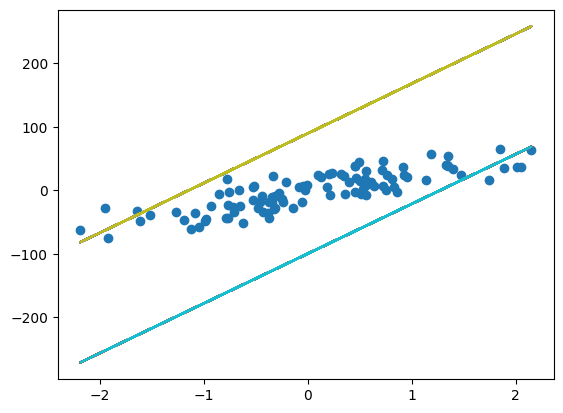

In [40]:


b = -100
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)
     